In [22]:
import pandas as pd
import seaborn as sns
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report

df = pd.read_csv('/content/academia_redfit.csv')
df

,idade,sexo,frequencia_semanal_treino,tipo_atividade,tempo_medio_exercicio,minutos_totais_semana,preco_plano,possui_nutricionista,primeiro_PGC,ultimo_PGC,data_matricula,estado
0,48,Outro,7.0,Natação,45.3,317.1,188.47,Não,39.5,24.9,2021-07-28,Ativa
1,30,Outro,7.0,Yoga,98.1,686.7,198.07,Não,25.2,23.5,2020-12-28,Ativa
2,35,Masculino,5.0,Cardio,33.9,169.5,154.90,Não,27.2,11.4,2022-02-27,Ativa
3,43,Outro,3.0,Yoga,75.6,226.8,250.79,Sim,14.4,19.2,2022-12-01,Ativa
4,37,Masculino,0.0,CrossFit,114.0,0.0,168.02,Sim,21.5,18.1,2024-01-20,Sedentária
...,...,...,...,...,...,...,...,...,...,...,...,...
995,43,Feminino,0.0,Futebol,101.7,0.0,215.21,Não,31.1,32.4,2024-04-24,Sedentária
996,39,Outro,5.0,Futebol,78.0,390.0,269.34,Sim,38.8,31.8,2022-11-02,Ativa
997,25,Feminino,2.0,Natação,112.3,224.6,130.93,Não,23.8,28.4,2025-01-24,Ativa
998,24,Masculino,4.0,CrossFit,113.8,455.2,149.22,Sim,30.5,35.7,2020-12-03,Ativa


In [23]:
df = df.drop_duplicates()

In [24]:
 df.isnull().sum()

,0
idade,0
sexo,0
frequencia_semanal_treino,51
tipo_atividade,0
tempo_medio_exercicio,46
minutos_totais_semana,95
preco_plano,0
possui_nutricionista,0
primeiro_PGC,0
ultimo_PGC,0


In [25]:
# Preencher todas as colunas numéricas com a mediana de cada uma
df.fillna(df.median(numeric_only=True), inplace=True)

# Verificar
df.isnull().sum()

,0
idade,0
sexo,0
frequencia_semanal_treino,0
tipo_atividade,0
tempo_medio_exercicio,0
minutos_totais_semana,0
preco_plano,0
possui_nutricionista,0
primeiro_PGC,0
ultimo_PGC,0


In [26]:
df['idade'].value_counts()

,count
idade,
23,34
25,31
37,31
62,28
54,27
55,27
21,26
35,26
42,26


In [27]:
df['sexo'].value_counts()

,count
sexo,
Masculino,349
Outro,340
Feminino,311


In [28]:
df['frequencia_semanal_treino'].value_counts()

,count
frequencia_semanal_treino,
4.0,192
5.0,134
2.0,118
7.0,117
0.0,115
3.0,110
6.0,109
1.0,105


In [29]:
df['tipo_atividade'].value_counts()

,count
tipo_atividade,
Yoga,195
Cardio,181
CrossFit,164
Musculação,160
Futebol,143
Natação,133
Fut,9
Swimming,6
Natacao,5


In [30]:
df['tempo_medio_exercicio'].value_counts()

,count
tempo_medio_exercicio,
70.55,46
106.80,5
77.20,5
115.70,5
20.90,5
...,...
114.30,1
67.50,1
45.50,1


In [31]:
df['preco_plano'].value_counts()

,count
preco_plano,
169.40,2
241.73,2
165.03,2
216.18,2
156.88,2
...,...
237.46,1
205.00,1
261.27,1


In [32]:
df['possui_nutricionista'].value_counts()

,count
possui_nutricionista,
Não,514
Sim,486


In [33]:
df['primeiro_PGC'].value_counts()

,count
primeiro_PGC,
30.4,12
32.1,9
25.3,9
27.3,8
39.2,8
...,...
11.1,1
12.2,1
31.9,1


In [34]:
df['ultimo_PGC'].value_counts()

,count
ultimo_PGC,
29.5,9
12.6,8
32.4,8
10.8,8
18.1,8
...,...
24.2,1
38.5,1
32.8,1


In [35]:
df['data_matricula'].value_counts()

,count
data_matricula,
2020-03-20,4
2021-07-29,4
2022-04-02,3
2021-07-23,3
2023-12-22,3
...,...
2024-11-27,1
2021-07-13,1
2020-06-05,1


In [36]:
df['estado'].value_counts()

,count
estado,
Ativa,834
Sedentária,166


In [37]:
# Corrigir nomes errados em tipo_atividade
df['tipo_atividade'] = df['tipo_atividade'].replace({
    'Natacao':  'Natação',
    'Swimming': 'Natação',
    'Fut':      'Futebol',
    'Soccer':   'Futebol',
})

# Converter data_matricula de texto para data
df['data_matricula'] = pd.to_datetime(df['data_matricula'])

# Criar novas métricas
df['evolucao_pgc'] = df['primeiro_PGC'] - df['ultimo_PGC']
df['imc_estimado'] = (1.2 * df['ultimo_PGC'] + 10.8).round(1)

In [38]:
# Criar a coluna que vamos prever (3 classes)
def classificar(row):
    if row['estado'] == 'Sedentária':
        return 'Sedentária'
    elif row['frequencia_semanal_treino'] >= 6 and row['minutos_totais_semana'] >= 407:
        return 'Atleta'
    else:
        return 'Ativa'

df['classificacao'] = df.apply(classificar, axis=1)
print(df['classificacao'].value_counts())

# Salvar versão limpa
df.to_csv('/content/academia_club4_limpo.csv', index=False)

classificacao
Ativa         710
Sedentária    166
Atleta        124
Name: count, dtype: int64


In [ ]:
le = LabelEncoder()
df['sexo_enc']          = le.fit_transform(df['sexo'])
df['atividade_enc']     = le.fit_transform(df['tipo_atividade'])
df['nutricionista_enc'] = le.fit_transform(df['possui_nutricionista'])

le_target    = LabelEncoder()
df['target'] = le_target.fit_transform(df['classificacao'])
classes      = le_target.classes_

# Separar o que o modelo vai usar para aprender (X) e o que vai prever (y)
X = df[['idade', 'sexo_enc', 'frequencia_semanal_treino', 'atividade_enc',
        'tempo_medio_exercicio', 'minutos_totais_semana', 'preco_plano',
        'nutricionista_enc', 'primeiro_PGC', 'ultimo_PGC',
        'evolucao_pgc', 'imc_estimado']]

y = df['target']

In [ ]:
x_treino, x_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler          = StandardScaler()
x_teste_original = x_teste.copy()       # guarda os valores originais para o gráfico
x_treino        = scaler.fit_transform(x_treino)  # aprende a escala no treino e transforma
x_teste         = scaler.transform(x_teste)        # só transforma, sem aprender


In [ ]:
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(x_treino, y_treino)

modelo = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
modelo.fit(x_treino, y_treino)

RandomForestClassifier(max_depth=5, random_state=42)

In [ ]:
previsao    = modelo.predict(x_teste)
previsao_lr = modelo_lr.predict(x_teste)

acuracia    = accuracy_score(y_teste, previsao)
acuracia_lr = accuracy_score(y_teste, previsao_lr)

matriz      = confusion_matrix(y_teste, previsao)
matriz_lr   = confusion_matrix(y_teste, previsao_lr)

In [ ]:

print(f"Acurácia (Random Forest)     : {acuracia * 100:.2f}%")
print(f"Matriz de confusão:\n{matriz}\n")

print(f"Acurácia (LR)                : {acuracia_lr * 100:.2f}%")
print(f"Matriz de confusão (LR):\n{matriz_lr}\n")

print("Relatório Detalhado — Random Forest")
print(classification_report(y_teste, previsao, target_names=classes))

Acurácia (Random Forest)     : 94.00%
Matriz de confusão:
[[142   0   0]
 [  3  22   0]
 [  9   0  24]]

Acurácia (LR)                : 87.50%
Matriz de confusão (LR):
[[139   0   3]
 [  3  22   0]
 [ 19   0  14]]

Relatório Detalhado — Random Forest
              precision    recall  f1-score   support

       Ativa       0.92      1.00      0.96       142
      Atleta       1.00      0.88      0.94        25
  Sedentária       1.00      0.73      0.84        33

    accuracy                           0.94       200
   macro avg       0.97      0.87      0.91       200
weighted avg       0.94      0.94      0.94       200



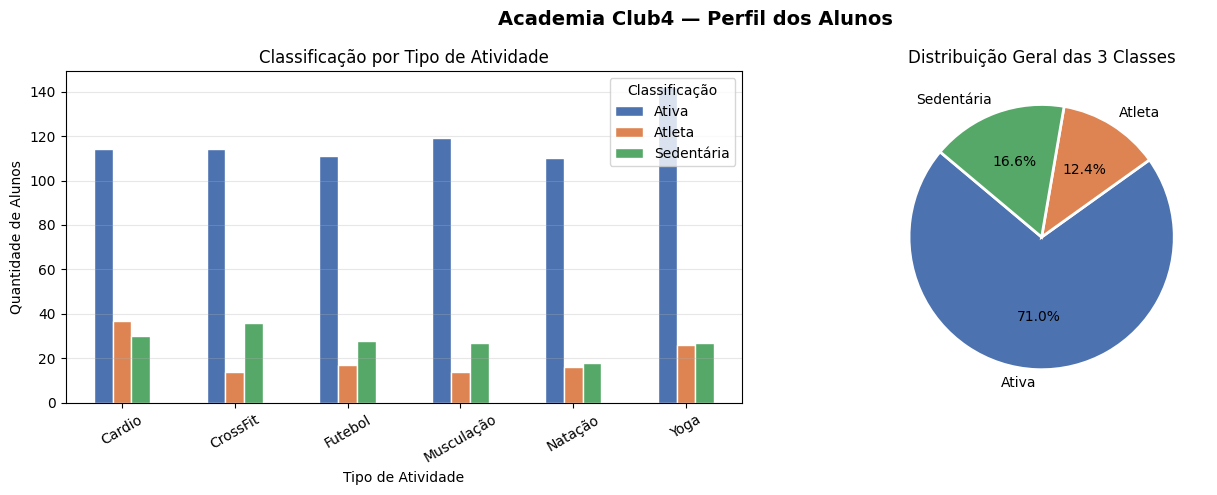

In [ ]:
cores = ['#4C72B0', '#DD8452', '#55A868']  # azul = Ativa, laranja = Atleta, verde = Sedentária

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Academia Club4 — Perfil dos Alunos', fontsize=14, fontweight='bold')

# ── Gráfico de Barras ──────────────────────────────────
# Mostra quantos alunos de cada classe existem por tipo de atividade
contagem = df.groupby(['tipo_atividade', 'classificacao']).size().unstack(fill_value=0)
contagem = contagem[['Ativa', 'Atleta', 'Sedentária']]  # define a ordem das barras

contagem.plot(kind='bar', ax=axes[0], color=cores, edgecolor='white')
axes[0].set_title('Classificação por Tipo de Atividade')
axes[0].set_xlabel('Tipo de Atividade')
axes[0].set_ylabel('Quantidade de Alunos')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Classificação')
axes[0].grid(axis='y', alpha=0.3)

# ── Gráfico de Pizza ───────────────────────────────────
# Mostra a proporção geral das 3 classes
contagem_geral = df['classificacao'].value_counts()[['Ativa', 'Atleta', 'Sedentária']]

axes[1].pie(
    contagem_geral,
    labels=contagem_geral.index,
    autopct='%1.1f%%',         # mostra a porcentagem em cada fatia
    colors=cores,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    startangle=140,            # rotação inicial do gráfico
)
axes[1].set_title('Distribuição Geral das 3 Classes')

plt.tight_layout()


<Figure size 640x480 with 0 Axes>